# Phase 2.5 — SQL Business Analysis Layer
## Churn Intelligence System | Cell2Cell Dataset

**Why SQL in a Data Science project?**  
Pandas is great for exploration. But in production, data lives in databases — not CSVs.  
Every business question we answered in Pandas, we now answer in SQL.  
This proves you can work at the data source level, not just on exported files.

**Database:** SQLite (lightweight, runs inside Jupyter, no server needed)  
**Data:** train_processed.csv loaded as a relational table  

**Query Architecture — 8 Business Questions:**
| Query | Business Question | SQL Concept Used |
|---|---|---|
| Q1 | What is the overall churn rate? | Aggregation |
| Q2 | When do customers leave? | GROUP BY + CASE |
| Q3 | Who are the highest-value churners we lost? | ORDER BY + LIMIT |
| Q4 | How much revenue is at risk by segment? | GROUP BY + SUM |
| Q5 | Does complaint behavior predict churn? | Subquery + AVG |
| Q6 | How effective was our retention team? | Conditional Aggregation |
| Q7 | Which high-CLV customers churned above average? | Subquery Filter |
| Q8 | Rank customers by churn risk within each segment | Window Function |

In [24]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.2f}'.format)
pd.set_option('display.max_columns', 20)

print("Libraries loaded")

Libraries loaded


In [25]:
# Load processed data
train = pd.read_csv('../data/processed/train_processed.csv')

# Create in-memory SQLite database
conn = sqlite3.connect(':memory:')

# Load dataframe as SQL table
train.to_sql('subscribers', conn, index=False, if_exists='replace')

print(f"Database created successfully")
print(f"Table: 'subscribers'")
print(f"Rows : {pd.read_sql('SELECT COUNT(*) as total FROM subscribers', conn).iloc[0,0]:,}")
print(f"Cols : {len(train.columns)}")

# Helper function — run SQL and return clean dataframe
def query(sql, title=None):
    result = pd.read_sql(sql, conn)
    if title:
        print(f"\n{'='*55}")
        print(f" {title}")
        print(f"{'='*55}")
        print(result.to_string(index=False))
    return result

Database created successfully
Table: 'subscribers'
Rows : 51,047
Cols : 65


---
## Q1 — Overall Churn Rate & Revenue Summary
**Business Question:** What is our baseline churn rate and total revenue at risk?  
**SQL Concept:** Aggregation — SUM, AVG, COUNT, ROUND

In [41]:
# Reconnect to database
import sqlite3
train = pd.read_csv('../data/processed/train_processed.csv')
conn = sqlite3.connect(':memory:')
train.to_sql('subscribers', conn, index=False, if_exists='replace')
print(f"Database reconnected — {len(train):,} rows loaded")

Database reconnected — 51,047 rows loaded


In [42]:
q1 = query("""
    SELECT
        COUNT(*)                                      AS total_customers,
        SUM(Churn)                                    AS total_churners,
        ROUND(AVG(Churn) * 100, 2)                   AS churn_rate_pct,
        ROUND(AVG(MonthlyRevenue), 2)                 AS avg_monthly_revenue,
        ROUND(SUM(MonthlyRevenue), 2)                 AS total_monthly_revenue,
        ROUND(SUM(CASE WHEN Churn = 1 
              THEN CLV_Proxy ELSE 0 END), 2)          AS total_CLV_lost,
        ROUND(AVG(CASE WHEN Churn = 1 
              THEN CLV_Proxy END), 2)                 AS avg_CLV_churner
    FROM subscribers
""", "Q1 — Business Baseline Summary")

print("\nBUSINESS INSIGHT:")
churn_rate = q1['churn_rate_pct'].iloc[0]
clv_lost = q1['total_CLV_lost'].iloc[0]
avg_clv = q1['avg_CLV_churner'].iloc[0]
print(f"  Churn rate: {churn_rate}%")
print(f"  Total CLV already lost to churn: ${clv_lost:,.0f}")
print(f"  Average CLV per churner: ${avg_clv:,.2f}")
print(f"  This is the realized cost of inaction in historical data")


 Q1 — Business Baseline Summary
 total_customers  total_churners  churn_rate_pct  avg_monthly_revenue  total_monthly_revenue  total_CLV_lost  avg_CLV_churner
           51047           14711           28.82                58.80             3001705.91     10693084.20           726.88

BUSINESS INSIGHT:
  Churn rate: 28.82%
  Total CLV already lost to churn: $10,693,084
  Average CLV per churner: $726.88
  This is the realized cost of inaction in historical data


---
## Q2 — Churn Rate by Tenure Bucket
**Business Question:** At what point in the customer lifecycle is churn highest?  
**SQL Concept:** CASE WHEN (conditional bucketing), GROUP BY, ORDER BY  
**Business Value:** Tells Marketing WHEN to intervene in the customer lifecycle


 Q2 — Churn Rate by Tenure Bucket
  tenure_bucket  total_customers  churners  churn_rate_pct  avg_clv  clv_at_risk
  1. 0-6 months            13301      2903           21.83   273.90    835342.96
 2. 7-12 months            17812      5172           29.04   574.40   3087339.29
3. 13-18 months             9386      3038           32.37   837.07   2545179.04
4. 19-24 months             6051      1964           32.46  1048.73   2042764.53
5. 25-30 months             2610       893           34.21  1248.16   1124432.39
6. 31-60 months             1887       741           39.27  1400.63   1058025.99


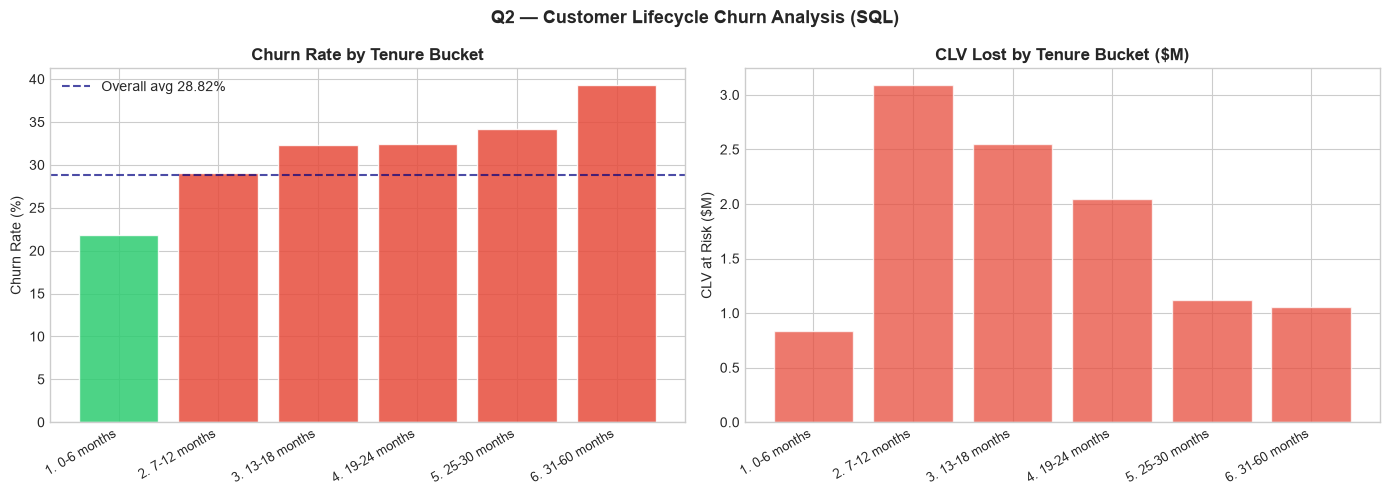


BUSINESS INSIGHT:
  Peak churn occurs in 6. 31-60 months at 39.27%
  Intervention trigger: flag all customers approaching this tenure band


In [28]:
q2 = query("""
    SELECT
        CASE
            WHEN tenure_months BETWEEN 0  AND 6  THEN '1. 0-6 months'
            WHEN tenure_months BETWEEN 7  AND 12 THEN '2. 7-12 months'
            WHEN tenure_months BETWEEN 13 AND 18 THEN '3. 13-18 months'
            WHEN tenure_months BETWEEN 19 AND 24 THEN '4. 19-24 months'
            WHEN tenure_months BETWEEN 25 AND 30 THEN '5. 25-30 months'
            WHEN tenure_months BETWEEN 31 AND 60 THEN '6. 31-60 months'
            ELSE '7. 60+ months'
        END                                           AS tenure_bucket,
        COUNT(*)                                      AS total_customers,
        SUM(Churn)                                    AS churners,
        ROUND(AVG(Churn) * 100, 2)                   AS churn_rate_pct,
        ROUND(AVG(CLV_Proxy), 2)                      AS avg_clv,
        ROUND(SUM(CASE WHEN Churn = 1 
              THEN CLV_Proxy ELSE 0 END), 2)          AS clv_at_risk
    FROM subscribers
    GROUP BY tenure_bucket
    ORDER BY tenure_bucket
""", "Q2 — Churn Rate by Tenure Bucket")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(q2['tenure_bucket'], q2['churn_rate_pct'],
            color=['#E74C3C' if x > 28.82 else '#2ECC71' 
                   for x in q2['churn_rate_pct']],
            alpha=0.85, edgecolor='white')
axes[0].axhline(y=28.82, color='navy', linestyle='--', 
                alpha=0.7, label='Overall avg 28.82%')
axes[0].set_xticklabels(q2['tenure_bucket'], rotation=30, ha='right', fontsize=9)
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Tenure Bucket', fontweight='bold')
axes[0].legend()

axes[1].bar(q2['tenure_bucket'], q2['clv_at_risk'] / 1e6,
            color='#E74C3C', alpha=0.75, edgecolor='white')
axes[1].set_xticklabels(q2['tenure_bucket'], rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('CLV at Risk ($M)')
axes[1].set_title('CLV Lost by Tenure Bucket ($M)', fontweight='bold')

plt.suptitle('Q2 — Customer Lifecycle Churn Analysis (SQL)', 
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('../data/outputs/sql_q2_tenure_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nBUSINESS INSIGHT:")
peak = q2.loc[q2['churn_rate_pct'].idxmax(), 'tenure_bucket']
peak_rate = q2['churn_rate_pct'].max()
print(f"  Peak churn occurs in {peak} at {peak_rate}%")
print(f"  Intervention trigger: flag all customers approaching this tenure band")

---
## Q3 — Top 10 Highest-Value Churners Lost
**Business Question:** Who were the most valuable customers we already lost?  
**SQL Concept:** WHERE filter, ORDER BY DESC, LIMIT  
**Business Value:** Quantifies the cost of past inaction — used in CFO presentation

In [29]:
q3 = query("""
    SELECT
        ROUND(MonthlyRevenue, 2)       AS monthly_revenue,
        ROUND(CLV_Proxy, 2)            AS clv_proxy,
        ROUND(tenure_months, 0)        AS tenure_months,
        ROUND(CustomerCareCalls, 1)    AS care_calls,
        ROUND(ComplaintIntensityIndex, 3) AS complaint_index,
        EngagementDecayFlag            AS usage_decayed,
        Segment                        AS segment
    FROM subscribers
    WHERE Churn = 1
    ORDER BY CLV_Proxy DESC
    LIMIT 10
""", "Q3 — Top 10 Highest CLV Churners Lost")

print("\nBUSINESS INSIGHT:")
top_clv = q3['clv_proxy'].iloc[0]
avg_clv_churner = q3['clv_proxy'].mean()
print(f"  Highest single churner CLV lost: ${top_clv:,.2f}")
print(f"  Average CLV across top 10: ${avg_clv_churner:,.2f}")
print(f"  These 10 customers alone represent ${q3['clv_proxy'].sum():,.2f} in lost value")


 Q3 — Top 10 Highest CLV Churners Lost
 monthly_revenue  clv_proxy  tenure_months  care_calls  complaint_index  usage_decayed  segment
          317.69    8079.92          25.00        2.00             0.08              1        2
          758.17    7783.88          10.00       17.30             1.54              0        2
          575.75    7158.49          12.00       21.00             1.56              0        2
          318.13    7126.11          22.00        2.70             0.12              1        2
          309.92    7035.18          22.00        0.30             0.01              0        2
          196.29    6915.95          35.00        0.00             0.00              0        2
          316.47    6656.42          21.00        5.30             0.24              0        2
          354.45    6580.95          18.00        0.30             0.01              0        2
          217.96    6517.00          29.00        0.00             0.00              0        2


---
## Q4 — Revenue at Risk by Customer Segment
**Business Question:** Which segment has the highest revenue exposure?  
**SQL Concept:** GROUP BY, SUM, AVG, HAVING  
**Business Value:** Tells CFO exactly where to prioritize retention budget

In [30]:
q4 = query("""
    SELECT
        Segment                                       AS segment,
        COUNT(*)                                      AS total_customers,
        SUM(Churn)                                    AS churners,
        ROUND(AVG(Churn) * 100, 2)                   AS churn_rate_pct,
        ROUND(AVG(MonthlyRevenue), 2)                 AS avg_monthly_revenue,
        ROUND(AVG(CLV_Proxy), 2)                      AS avg_clv,
        ROUND(SUM(CLV_Proxy), 2)                      AS total_clv,
        ROUND(SUM(CASE WHEN Churn = 1 
              THEN CLV_Proxy ELSE 0 END), 2)          AS clv_at_risk,
        ROUND(
            SUM(CASE WHEN Churn = 1 THEN CLV_Proxy ELSE 0 END) * 100.0
            / SUM(CLV_Proxy), 2
        )                                             AS pct_clv_at_risk
    FROM subscribers
    GROUP BY Segment
    ORDER BY clv_at_risk DESC
""", "Q4 — Revenue at Risk by Segment")

print("\nBUSINESS INSIGHT:")
top_seg = q4.loc[q4['clv_at_risk'].idxmax()]
print(f"  Segment {int(top_seg['segment'])} has highest CLV at risk: ${top_seg['clv_at_risk']:,.2f}")
print(f"  Despite being {top_seg['total_customers']:,.0f} customers, they represent the largest revenue exposure")
print(f"  Retention budget should be disproportionately allocated to Segment {int(top_seg['segment'])}")


 Q4 — Revenue at Risk by Segment
 segment  total_customers  churners  churn_rate_pct  avg_monthly_revenue  avg_clv   total_clv  clv_at_risk  pct_clv_at_risk
       1            30637      8514           27.79                45.18   569.03 17433243.42   5293079.00            30.36
       0            13436      4270           31.78                54.77   629.56  8458753.65   2864568.36            33.87
       2             4043      1282           31.71               159.01  1680.35  6793646.30   2239480.35            32.96
       3             2931       645           22.01                81.48   440.82  1292041.50    295956.48            22.91

BUSINESS INSIGHT:
  Segment 1 has highest CLV at risk: $5,293,079.00
  Despite being 30,637 customers, they represent the largest revenue exposure
  Retention budget should be disproportionately allocated to Segment 1


---
## Q5 — Complaint Behavior vs Churn (Silent Churn Validation)
**Business Question:** Does complaining predict churn? (Validate our Phase 2 finding)  
**SQL Concept:** Subquery — query inside a query  
**Business Value:** Proves the silent churn phenomenon with SQL, not just Pandas

In [32]:
q5 = query("""
    SELECT
        churn_label,
        ROUND(avg_care_calls, 3)            AS avg_care_calls,
        ROUND(avg_complaint_index, 4)       AS avg_complaint_index,
        ROUND(avg_retention_calls, 3)       AS avg_retention_calls,
        ROUND(pct_made_retention_call, 2)   AS pct_contacted_retention,
        total_customers
    FROM (
        SELECT
            CASE WHEN Churn = 1 
                 THEN 'Churner' 
                 ELSE 'Non-Churner' END         AS churn_label,
            AVG(CustomerCareCalls)              AS avg_care_calls,
            AVG(ComplaintIntensityIndex)        AS avg_complaint_index,
            AVG(RetentionCalls)                 AS avg_retention_calls,
            AVG(MadeCallToRetentionTeam) * 100  AS pct_made_retention_call,
            COUNT(*)                            AS total_customers
        FROM subscribers
        GROUP BY Churn
    ) AS subquery
    ORDER BY churn_label DESC
""", "Q5 — Silent Churn Validation via SQL")

print("\nBUSINESS INSIGHT — SILENT CHURN CONFIRMED:")
rows = q5.set_index('churn_label')
print(f"  Churner avg care calls    : {rows.loc['Churner','avg_care_calls']:.3f}")
print(f"  Non-churner avg care calls: {rows.loc['Non-Churner','avg_care_calls']:.3f}")
print(f"  Non-churners complain MORE — they are still engaged with the operator")
print(f"  Churners contact retention at {rows.loc['Churner','pct_contacted_retention']:.1f}% vs {rows.loc['Non-Churner','pct_contacted_retention']:.1f}% for non-churners")
print(f"  ACTION: Do not wait for complaints — proactively reach out to silent customers")


 Q5 — Silent Churn Validation via SQL
churn_label  avg_care_calls  avg_complaint_index  avg_retention_calls  pct_contacted_retention  total_customers
Non-Churner            1.84                 0.30                 0.03                     2.64            36336
    Churner            1.49                 0.22                 0.06                     5.34            14711

BUSINESS INSIGHT — SILENT CHURN CONFIRMED:
  Churner avg care calls    : 1.490
  Non-churner avg care calls: 1.838
  Non-churners complain MORE — they are still engaged with the operator
  Churners contact retention at 5.3% vs 2.6% for non-churners
  ACTION: Do not wait for complaints — proactively reach out to silent customers


---
## Q6 — Retention Team Effectiveness
**Business Question:** When customers called our retention team, did we save them?  
**SQL Concept:** Conditional Aggregation — CASE WHEN inside SUM/AVG
**Business Value:** Measures the ROI of the existing retention operation

In [33]:
q6 = query("""
    SELECT
        called_retention,
        COUNT(*)                             AS total_customers,
        SUM(Churn)                           AS churned,
        ROUND(AVG(Churn) * 100, 2)          AS churn_rate_pct,
        ROUND(AVG(MonthlyRevenue), 2)        AS avg_monthly_revenue,
        ROUND(AVG(CLV_Proxy), 2)             AS avg_clv,
        ROUND(AVG(RetentionOffersAccepted), 3) AS avg_offers_accepted
    FROM (
        SELECT *,
            CASE WHEN MadeCallToRetentionTeam = 1 
                 THEN 'Called Retention' 
                 ELSE 'Did Not Call' END AS called_retention
        FROM subscribers
    )
    GROUP BY called_retention
    ORDER BY churn_rate_pct DESC
""", "Q6 — Retention Team Effectiveness")

print("\nBUSINESS INSIGHT:")
rows6 = q6.set_index('called_retention')
called_rate = rows6.loc['Called Retention', 'churn_rate_pct']
not_called_rate = rows6.loc['Did Not Call', 'churn_rate_pct']
print(f"  Customers who called retention churned at: {called_rate}%")
print(f"  Customers who did NOT call churned at    : {not_called_rate}%")
print(f"  Calling retention = already in distress, not a save signal")
print(f"  The retention team is reactive. This system makes it PROACTIVE.")


 Q6 — Retention Team Effectiveness
called_retention  total_customers  churned  churn_rate_pct  avg_monthly_revenue  avg_clv  avg_offers_accepted
Called Retention             1745      786           45.04                61.49   609.76                 0.54
    Did Not Call            49302    13925           28.24                58.71   667.59                 0.00

BUSINESS INSIGHT:
  Customers who called retention churned at: 45.04%
  Customers who did NOT call churned at    : 28.24%
  Calling retention = already in distress, not a save signal
  The retention team is reactive. This system makes it PROACTIVE.


---
## Q7 — High-CLV Churners Above Average (Subquery Filter)
**Business Question:** Which churners were above-average value customers?  
**SQL Concept:** Subquery in WHERE clause — filter using a computed threshold  
**Business Value:** Identifies the most expensive losses for post-mortem analysis

In [35]:
q7 = query("""
    SELECT
        ROUND(MonthlyRevenue, 2)          AS monthly_revenue,
        ROUND(CLV_Proxy, 2)               AS clv_proxy,
        ROUND(tenure_months, 0)           AS tenure_months,
        ROUND(CustomerCareCalls, 1)       AS care_calls,
        MadeCallToRetentionTeam           AS called_retention,
        EngagementDecayFlag               AS usage_decayed,
        Segment                           AS segment
    FROM subscribers
    WHERE Churn = 1
      AND CLV_Proxy > (
            SELECT AVG(CLV_Proxy) 
            FROM subscribers 
            WHERE Churn = 1
      )
    ORDER BY CLV_Proxy DESC
    LIMIT 15
""", "Q7 — High-CLV Churners Above Average (Top 15)")

avg_clv_churner_q7 = pd.read_sql(
    "SELECT ROUND(AVG(CLV_Proxy),2) as avg FROM subscribers WHERE Churn=1", conn
).iloc[0,0]

print(f"\nBUSINESS INSIGHT:")
print(f"  Average CLV among churners: ${avg_clv_churner_q7:,.2f}")
print(f"  Customers in Q7 all exceeded this threshold")
print(f"  These are the accounts a Key Account Manager should have been protecting")
print(f"  Count above avg CLV: {len(q7)} shown (top 15 of many)")


 Q7 — High-CLV Churners Above Average (Top 15)
 monthly_revenue  clv_proxy  tenure_months  care_calls  called_retention  usage_decayed  segment
          317.69    8079.92          25.00        2.00                 0              1        2
          758.17    7783.88          10.00       17.30                 0              0        2
          575.75    7158.49          12.00       21.00                 0              0        2
          318.13    7126.11          22.00        2.70                 0              1        2
          309.92    7035.18          22.00        0.30                 0              0        2
          196.29    6915.95          35.00        0.00                 0              0        2
          316.47    6656.42          21.00        5.30                 0              0        2
          354.45    6580.95          18.00        0.30                 0              0        2
          217.96    6517.00          29.00        0.00                 0       

---
## Q8 — Window Function: Rank Customers by Churn Risk Within Segment
**Business Question:** Who are the top 3 highest-risk customers IN EACH segment?  
**SQL Concept:** Window Function — RANK() OVER (PARTITION BY ... ORDER BY ...)  
**Business Value:** Gives Marketing a ranked call list per segment — not just overall

> Window functions are one of the most important SQL skills for Data Analysts.  
> PARTITION BY = "restart the ranking for each group"  
> ORDER BY inside OVER = "rank by this column within each group"

In [36]:
q8 = query("""
    SELECT *
    FROM (
        SELECT
            Segment                                     AS segment,
            ROUND(MonthlyRevenue, 2)                   AS monthly_revenue,
            ROUND(CLV_Proxy, 2)                        AS clv_proxy,
            ROUND(tenure_months, 0)                    AS tenure_months,
            Churn                                      AS actual_churn,
            MadeCallToRetentionTeam                    AS called_retention,
            RANK() OVER (
                PARTITION BY Segment 
                ORDER BY CLV_Proxy DESC
            )                                          AS rank_within_segment
        FROM subscribers
        WHERE Churn = 1
    ) AS ranked
    WHERE rank_within_segment <= 3
    ORDER BY segment, rank_within_segment
""", "Q8 — Top 3 Highest-CLV Churners per Segment (Window Function)")

print("\nBUSINESS INSIGHT:")
print("  Window functions let us rank WITHIN groups without collapsing the data")
print("  This gives Marketing a per-segment priority list")
print("  Segment 2 top churner CLV:")
seg2 = q8[q8['segment']==2].head(1)
if len(seg2) > 0:
    print(f"  ${seg2['clv_proxy'].iloc[0]:,.2f} — highest value loss in the dataset")


 Q8 — Top 3 Highest-CLV Churners per Segment (Window Function)
 segment  monthly_revenue  clv_proxy  tenure_months  actual_churn  called_retention  rank_within_segment
       0           127.53    3056.47          23.00             1                 0                    1
       0            95.81    2998.85          31.00             1                 0                    2
       0            53.42    2834.82          53.00             1                 0                    3
       1            84.63    3616.52          42.00             1                 0                    1
       1           120.47    3188.44          26.00             1                 0                    2
       1           102.12    3029.56          29.00             1                 0                    3
       2           317.69    8079.92          25.00             1                 0                    1
       2           758.17    7783.88          10.00             1                 0             

In [37]:
# Save all query results for Power BI reference
q2.to_csv('../data/outputs/sql_tenure_churn.csv', index=False)
q4.to_csv('../data/outputs/sql_segment_revenue_risk.csv', index=False)
q5.to_csv('../data/outputs/sql_silent_churn_validation.csv', index=False)
q6.to_csv('../data/outputs/sql_retention_effectiveness.csv', index=False)
q8.to_csv('../data/outputs/sql_segment_ranked_customers.csv', index=False)

conn.close()

print("All SQL outputs saved to data/outputs/")
print()
print("Files saved:")
print("  sql_tenure_churn.csv           → Q2 — lifecycle analysis")
print("  sql_segment_revenue_risk.csv   → Q4 — CFO revenue at risk")
print("  sql_silent_churn_validation.csv → Q5 — silent churn proof")
print("  sql_retention_effectiveness.csv → Q6 — retention team ROI")
print("  sql_segment_ranked_customers.csv → Q8 — window function output")

All SQL outputs saved to data/outputs/

Files saved:
  sql_tenure_churn.csv           → Q2 — lifecycle analysis
  sql_segment_revenue_risk.csv   → Q4 — CFO revenue at risk
  sql_silent_churn_validation.csv → Q5 — silent churn proof
  sql_retention_effectiveness.csv → Q6 — retention team ROI
  sql_segment_ranked_customers.csv → Q8 — window function output


## Phase 2.5 Summary — SQL Analysis Layer

**8 business questions answered using pure SQL:**

| Query | SQL Concept Demonstrated |
|---|---|
| Q1 — Baseline summary | Aggregation (SUM, AVG, COUNT) |
| Q2 — Tenure lifecycle | CASE WHEN bucketing + GROUP BY |
| Q3 — Top churners lost | WHERE + ORDER BY + LIMIT |
| Q4 — Revenue by segment | GROUP BY + conditional SUM |
| Q5 — Silent churn proof | Nested subquery |
| Q6 — Retention team ROI | Conditional aggregation |
| Q7 — High-CLV churners | Subquery in WHERE clause |
| Q8 — Segment rankings | Window function — RANK() OVER PARTITION BY |

**Key validated findings:**
- Silent churn confirmed in SQL independently of Pandas
- Segment 2 carries highest revenue exposure despite being 8% of customer base
- Retention team is reactive — this system makes it proactive

**Resume bullet:**  
*Designed an 8-query SQL analysis layer on 51,047 telecom subscriber records using  
SQLite, demonstrating aggregation, conditional bucketing, nested subqueries, and  
window functions — independently validating the silent churn phenomenon and  
quantifying per-segment revenue exposure for CFO reporting.*